In [14]:
! pip3 install seaborn

In [15]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn

In [16]:
df = pd.read_csv("../Data/mpg.csv")

In [17]:
df.head(2)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    str    
 8   name          398 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 28.1 KB


In [19]:
df = df.drop(columns = ['name', 'origin'])
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].median())
df.head(2)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
0,18.0,8,307.0,130.0,3504,12.0,70
1,15.0,8,350.0,165.0,3693,11.5,70


In [20]:
x=df.drop(columns=["mpg"])
y=df["mpg"]

In [21]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(x_train.shape, x_test.shape)

(318, 6) (80, 6)


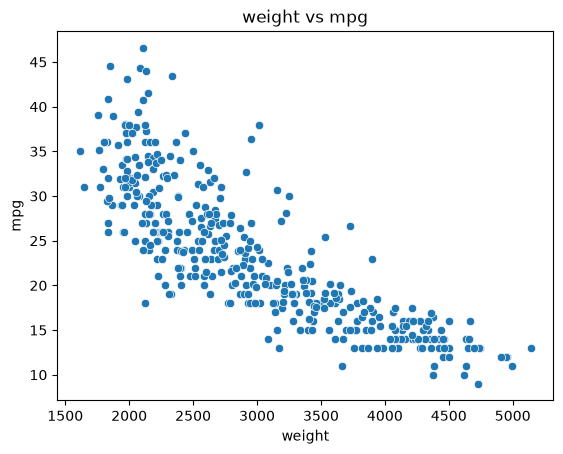

In [22]:
sns.scatterplot(data = df, x = 'weight', y = 'mpg')
plt.title('weight vs mpg')
plt.show()

In [23]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train[['weight']], y_train)

print("coef: ", model.coef_)
print(("intercept:", model.intercept_))

coef:  [-0.00780524]
('intercept:', np.float64(46.78206336645047))


In [ ]:
# R2 SCORE (if value tending to 1 then model is more efficient)
print(model.score(x_test[['weight']], y_test))

0.722971057303075


<function matplotlib.pyplot.show(close=None, block=None)>

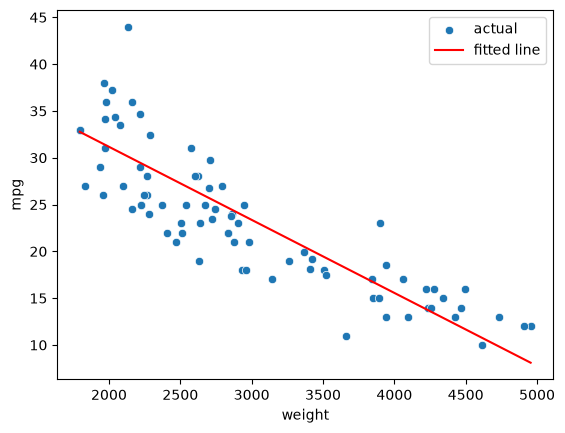

In [25]:
sns.scatterplot(x = x_test['weight'], y = y_test, label = 'actual')
sns.lineplot(x = x_test['weight'], y = model.predict(x_test[['weight']]),
            color = 'red', label = 'fitted line')
plt.show

In [26]:
model_all = LinearRegression()
model_all.fit(x_train, y_train)
print(model_all.score(x_test, y_test))

0.8244245330943358


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model_all.predict(x_test)